# **Intro to Graph Theory - Colab 06. 22.05.2026**

NetworkX is one of the most frequently used Python packages to create, manipulate, and mine graphs.

With NetworkX you can load and store networks in standard and nonstandard data formats, generate many types of random and classic networks, analyze network structure, build network models, design new network algorithms, draw networks, and much more.

Library documentation: <a>https://networkx.org/documentation/stable/</a> .

# Setup

In [2]:
# Import the NetworkX package and some other may-be-useful packages
import itertools
import copy
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mpl
import random as rnd

# Network science

Networks pervade all aspects of our lives: networks of friends, communication, computers, the Web, and transportation are examples we experience daily, while networks in our brain and cells determine our very survival. The network is a general yet powerful way to represent and study simple and complex relationships.

The scientific study of networks, such as computer networks, biological networks, and social networks, is an interdisciplinary field that combines ideas from mathematics, physics, biology, computer science, statistics, the social sciences, and many other areas.

An introduction to some of the standard measures for
quantifying network structure, including measures of
centrality, transitivity, and modularity

## Basic topological attributes
Total number of nodes in network:

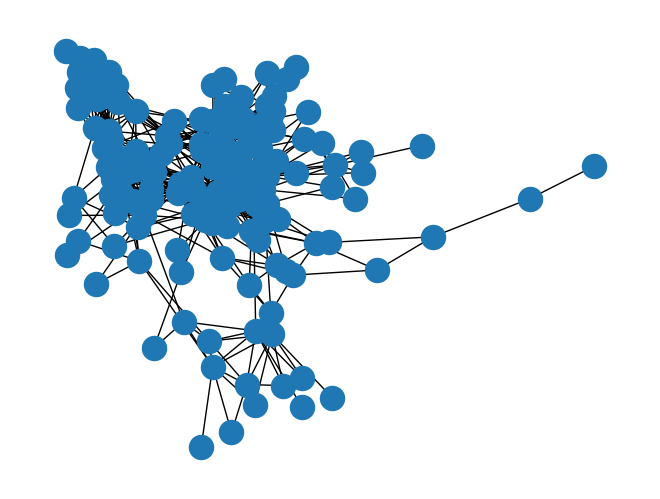

In [5]:
G = nx.read_edgelist('ia-enron-only.edges', nodetype=int)

nx.draw(G)

In [3]:
# Total number of nodes in network:
G.number_of_nodes()

143

Total number of nodes in network:

In [ ]:
G.number_of_nodes()#prameter 一定为\le n-1

143

Total number of edges:

In [5]:
G.number_of_edges()

623

In [ ]:
143*(143-1)/2#至多有的edges————C_n^2

10153.0

Also, the average degree of a node can be seen.
* On average, a node is connected to almost 9 other nodes, also known as neighbors of the node.
* This has been calculated by creating a list of all the degrees of the nodes and using `numpy.array` to find the mean of the created list.

In [7]:
[d for _, d in G.degree()]

[30,
 2,
 17,
 12,
 13,
 16,
 17,
 10,
 11,
 18,
 20,
 15,
 16,
 16,
 11,
 19,
 17,
 11,
 10,
 7,
 14,
 2,
 12,
 9,
 11,
 10,
 11,
 16,
 10,
 13,
 11,
 42,
 8,
 5,
 6,
 8,
 18,
 15,
 9,
 2,
 17,
 11,
 14,
 7,
 18,
 9,
 8,
 6,
 14,
 14,
 7,
 14,
 17,
 10,
 9,
 16,
 11,
 8,
 9,
 1,
 9,
 4,
 6,
 9,
 5,
 8,
 19,
 4,
 9,
 14,
 6,
 6,
 7,
 23,
 12,
 9,
 10,
 12,
 3,
 10,
 5,
 3,
 7,
 5,
 2,
 3,
 5,
 3,
 7,
 13,
 4,
 4,
 7,
 5,
 9,
 3,
 2,
 10,
 12,
 8,
 10,
 2,
 11,
 3,
 1,
 2,
 9,
 9,
 9,
 7,
 11,
 4,
 15,
 3,
 4,
 4,
 9,
 5,
 9,
 7,
 1,
 9,
 2,
 4,
 2,
 3,
 2,
 1,
 4,
 6,
 4,
 3,
 2,
 6,
 2,
 2,
 1,
 2,
 2,
 1,
 5,
 4,
 2]

In [8]:
np.mean([d for _, d in G.degree()])

np.float64(8.713286713286713)

There are many interesting properties related to the distribution of *paths*
through the graph.
For example, the *diameter* of a graph represents the longest of the
shortest-paths that connect any node to another node in the Graph.
Similarly, the average path length gives a measure of the average number of
edges to be traversed to get from one node to another in the network.
These attributes can be calculated with the `nx.diameter` and
`nx.average_shortest_path_length` functions, respectively.
Note however that these analyses require computing the shortest path between
every pair of nodes in the network: this can be quite expensive for networks
of this size!
Since we're interested in several analyses involving the shortest path length
for all nodes in the network, we can instead compute this once and reuse the
information to save computation time.

Let's start by computing the shortest path length for all pairs of nodes in the
network:

In [ ]:
shortest_path_lengths = dict(nx.all_pairs_shortest_path_length(G))

`nx.all_pairs_shortest_path_length` returns a dict-of-dict that maps a node `u`
to all other nodes in the network, where the inner-most mapping returns the
length of the shortest path between the two nodes.
In other words, `shortest_path_lengths[u][v]` will return the shortest path
length between any two pair of nodes `u` and `v`:

In [ ]:
shortest_path_lengths[1][100]  # Length of shortest path between nodes 1 and 42

3

Now let's use `shortest_path_lengths` to perform our analyses, starting with
the *diameter* of `G`.
If we look carefully at the [docstring for `nx.diameter`][nx_diameter_], we see
that it is equivalent to the maximum *eccentricity* of the graph.
It turns out that `nx.eccentricity` has an optional argument `sp` where we can
pass in our pre-computed `shortest_path_lengths` to save the extra computation:

In [ ]:
# This is equivalent to `diameter = nx.diameter(G), but much more efficient since we're
# reusing the pre-computed shortest path lengths!
diameter = max(nx.eccentricity(G, sp=shortest_path_lengths).values())
diameter#随机两个点之间的最短直径

8

[nx_diameter_]: https://networkx.org/documentation/latest/reference/algorithms/generated/networkx.algorithms.distance_measures.diameter.html

In order to connect from one node to any other one we would have to traverse 8
edges or fewer.

Next up, the average path length is found.
Again, we could use `nx.average_shortest_path_length` to compute this
directly, but it's much more efficient to use the `shortest_path_length` that
we've already computed:

In [ ]:
# Compute the average shortest path length for each node
average_path_lengths = [
    np.mean(list(spl.values())) for spl in shortest_path_lengths.values()
]
# The average over all nodes
np.mean(average_path_lengths)

2.946256540662135

This represents the average of the shortest path length for all pairs of nodes:
in order to reach from one node to another node, roughly 2.9 edges will be
traversed on average.

The above measures capture useful information about the network, but metrics
like the average value represent only a moment of the distribution; it is
also often valuable to look at the *distribution* itself.
Again, we can construct a visualization of the distribution of shortest path
lengths from our pre-computed dict-of-dicts:

Text(0, 0.5, 'Frequency (%)')

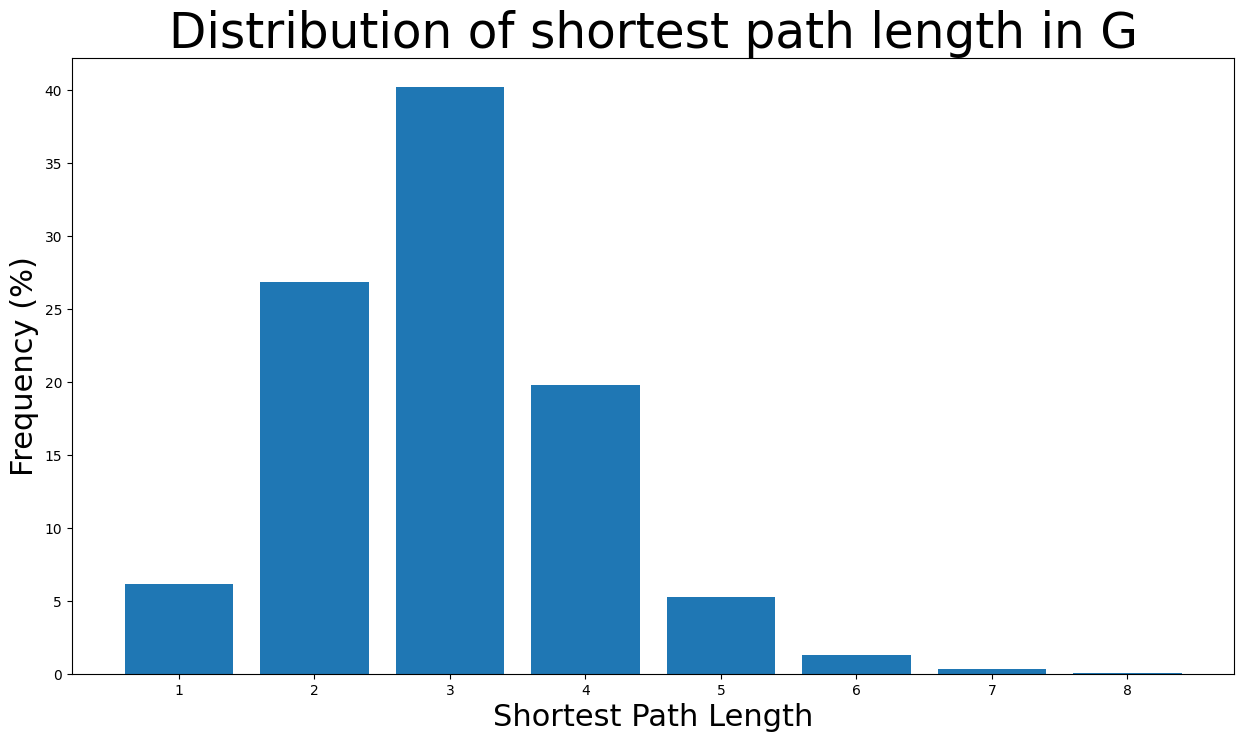

In [ ]:
# We know the maximum shortest path length (the diameter), so create an array
# to store values from 0 up to (and including) diameter
path_lengths = np.zeros(diameter + 1, dtype=int)

# Extract the frequency of shortest path lengths between two nodes
for pls in shortest_path_lengths.values():
    pl, cnts = np.unique(list(pls.values()), return_counts=True)
    path_lengths[pl] += cnts

# Express frequency distribution as a percentage (ignoring path lengths of 0)
freq_percent = 100 * path_lengths[1:] / path_lengths[1:].sum()

# Plot the frequency distribution (ignoring path lengths of 0) as a percentage
fig, ax = plt.subplots(figsize=(15, 8))
ax.bar(np.arange(1, diameter + 1), height=freq_percent)
ax.set_title(
    "Distribution of shortest path length in G", fontdict={"size": 35}, loc="center"
)
ax.set_xlabel("Shortest Path Length", fontdict={"size": 22})
ax.set_ylabel("Frequency (%)", fontdict={"size": 22})

In [ ]:
freq_percent

array([ 6.1361174 , 26.88860435, 40.22456417, 19.7971043 ,  5.2595292 ,
        1.30995765,  0.30532847,  0.07879444])

The majority of the shortest path lengths are from $2$ to $5$ edges long.
Also, it's highly unlikely for a pair of nodes to have a shortest path of length 8 (diameter length) as the likelihood is less than $0.1$%.

The graph's density is calculated here. Clearly, the graph is a very sparse one as: $density < 1$

The density for undirected graphs is $$d = \frac{2m}{n(n-1)}, $$
where $n$ is the number of nodes and $m$  is the number of edges in $G$.

In [ ]:
nx.density(G)

0.061361174037230376

The graph's number of components are found below. As expected, the network consists of one giant component:

In [ ]:
nx.number_connected_components(G)

1

## Centrality measures

Often when looking at a network, we want to find the most "important" nodes, for some definition of important.

A large volume of research on networks has been devoted to the concept of centrality.
This research addresses the question, “Which are the most important
or central nodes in a network?” There are many possible definitions of importance and there are correspondingly many centrality measures for networks.
We describe some of the most widely used such measures.

### Degree centrality

Perhaps the simplest centrality measure for a node in a network is just its degree, the number of edges connected to it. Degree is sometimes
called degree centrality in the social networks literature, to emphasize its use as a centrality measure.

Degree centrality assigns an importance score based simply on the number of links held by each node. In this analysis, that means that the higher the degree centrality of a node is, the more edges are connected to the particular node and thus the more neighbor nodes this node has. In fact, the degree of centrality of a node is the fraction of nodes it is connected to. In other words, it is the percentage of the network that the particular node is connected to meaning being friends with.

The degree centrality values are normalized by dividing by the maximum possible degree in a simple graph $n-1$ where $n$ is the number of nodes in $G$.

$$C_D(v) = \frac{\deg(v)}{n-1}.$$

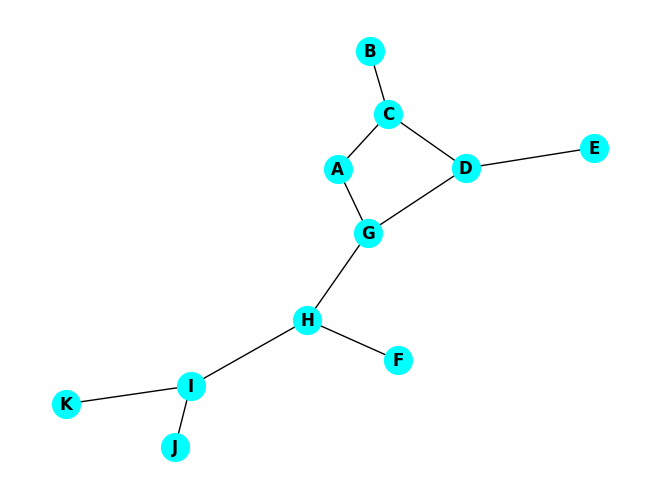

In [ ]:
H = nx.Graph()
H.add_nodes_from(["A","B","C","D","E","F","G","H","I","J","K"])

H.add_edges_from([("A","C"),("B","C"),("C","D"),("D","E"),
("D","G"),("A","G"),("F","H"),("G","H"),("H","I"),
("I","J"),("I","K")])

nx.draw(H, node_size=400, node_color='cyan', with_labels=True, font_weight='bold')

In [ ]:
degree_lst = [H.degree(v) for v in H.nodes]

degree_lst

[2, 1, 3, 3, 1, 1, 3, 3, 3, 1, 1]

In [ ]:
# Degree centrality measure for nodes in H
[H.degree(v)/(H.number_of_edges() - 1) for v in H.nodes]

[0.2, 0.1, 0.3, 0.3, 0.1, 0.1, 0.3, 0.3, 0.3, 0.1, 0.1]

In [ ]:
nx.degree_centrality(H)

{'A': 0.2,
 'B': 0.1,
 'C': 0.30000000000000004,
 'D': 0.30000000000000004,
 'E': 0.1,
 'F': 0.1,
 'G': 0.30000000000000004,
 'H': 0.30000000000000004,
 'I': 0.30000000000000004,
 'J': 0.1,
 'K': 0.1}

We find the nodes with the highest degree centralities in graph $G$. Specifically, the nodes with the 10 highest degree centralities are shown below together with the degree centrality:

In [ ]:
degree_centrality = nx.centrality.degree_centrality(G)

# save results in a variable to use again
(sorted(degree_centrality.items(), key=lambda item: item[1], reverse=True))[:10]

[(105, 0.29577464788732394),
 (17, 0.2112676056338028),
 (95, 0.1619718309859155),
 (48, 0.14084507042253522),
 (132, 0.13380281690140847),
 (43, 0.13380281690140847),
 (31, 0.1267605633802817),
 (74, 0.1267605633802817),
 (91, 0.1267605633802817),
 (72, 0.11971830985915494)]

That means that node $105$ has the highest degree centrality with $0.296$, meaning that this facebook user is friends with around the 30% of the whole network. Similarly, nodes $17$ and $95$ also have very high degree centralities.

In [ ]:
(sorted(G.degree, key=lambda item: item[1], reverse=True))[:10]

[(105, 42),
 (17, 30),
 (95, 23),
 (48, 20),
 (132, 19),
 (43, 19),
 (31, 18),
 (74, 18),
 (91, 18),
 (72, 17)]

As expected, node $105$ has $42$ "friends" which is the most any node has in the graph $G$.

Now the distribution of degree centralities will be plotted:

Text(0, 0.5, 'Counts')

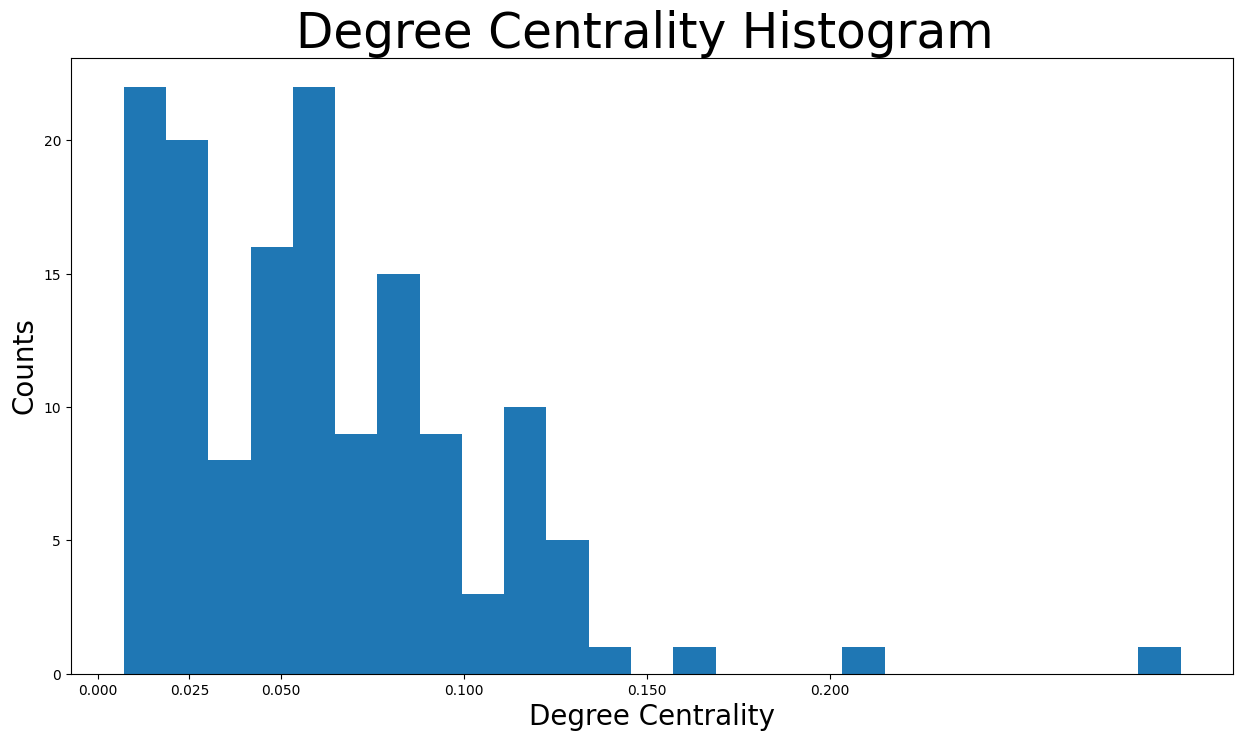

In [ ]:
plt.figure(figsize=(15, 8))
plt.hist(degree_centrality.values(), bins=25)
plt.xticks(ticks=[0, 0.025, 0.05, 0.1, 0.15, 0.2])  # set the x axis ticks
plt.title("Degree Centrality Histogram ", fontdict={"size": 35}, loc="center")
plt.xlabel("Degree Centrality", fontdict={"size": 20})
plt.ylabel("Counts", fontdict={"size": 20})

(-0.7677073005632016,
 1.1679721869313449,
 -0.8943930219251253,
 0.893899762456923)

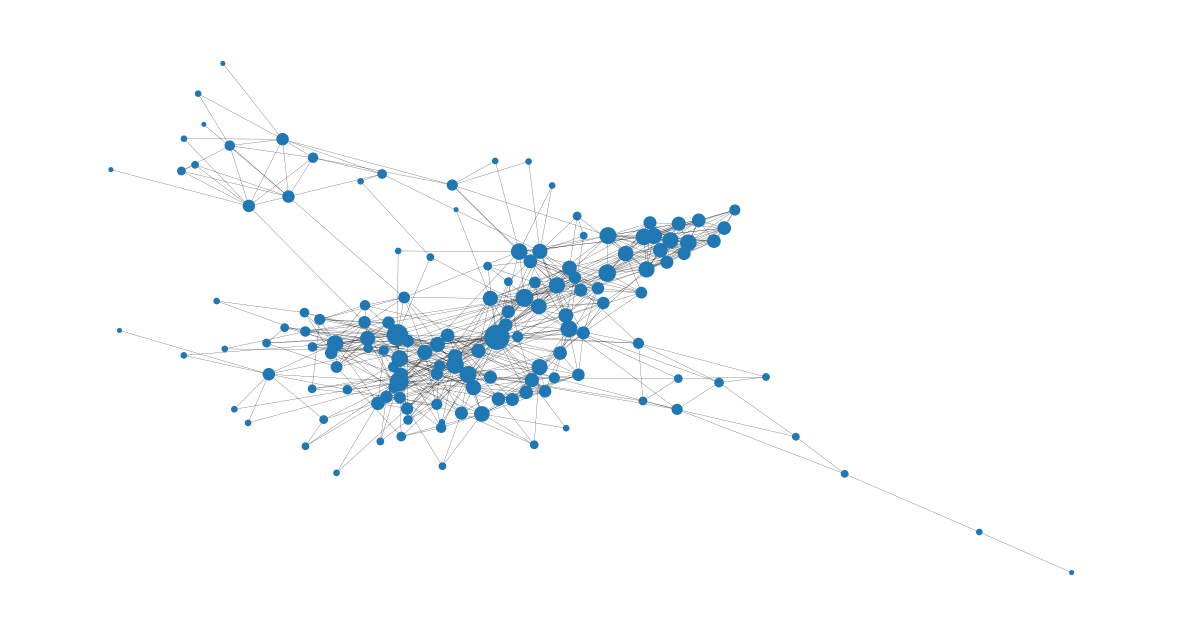

In [ ]:
# set up nodes size for a nice graph representation
node_size = [ v * 1000 for v in degree_centrality.values()]

plt.figure(figsize=(15, 8))
nx.draw_networkx(G, node_size=node_size, with_labels=False, width=0.15)
plt.axis("off")

### Closeness Centrality
Closeness centrality scores each node based on their ‘closeness’ to all other nodes in the network. For a node $v$, its closeness centrality measures the average farness to all other nodes. In other words, the higher the closeness centrality of $v$, the closer it is located to the center of the network.


The closeness centrality measure is very important for the monitoring of the spread of false information (e.g. fake news) or viruses (e.g. malicious links that gain control of the facebook account in this case). Let's examine the example of fake news. If the user with the highest closeness centrality measure started spreading some fake news information (sharing or creating a post), the whole network would get missinformed the quickest possible. However, if a user with very low closeness centrality would try the same, the spread of the missinformation to the whole network would be much slower. That is because the false information would have to firstly reach a user with high closeness centrality that would spread it to many different parts of the network.

Closeness centrality of a node $u$ is the reciprocal of the average shortest path distance to $u$ over all $n-1$ reachable nodes.

$$ C_C(u) = \frac{n - 1}{\sum_{v=1}^{n-1} l(v, u)}, $$

where $l(v, u)$ is the shortest-path distance between $v$ and $u$,  and $n-1$ is the number of nodes reachable from $u$.

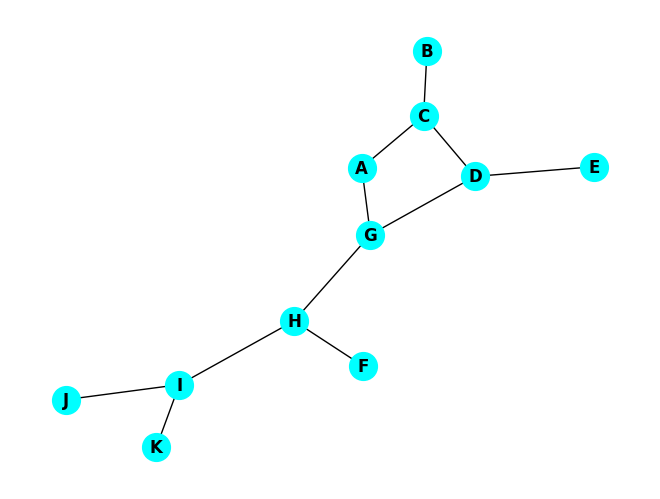

In [ ]:
nx.draw(H, node_size=400, node_color='cyan', with_labels=True, font_weight='bold')

Calculate closeness centrality for nodes $A$, $B$.

In [ ]:
shortest_path_lengths_H = dict(nx.all_pairs_shortest_path_length(H))

shortest_path_lengths_H["A"]

{'A': 0,
 'C': 1,
 'G': 1,
 'B': 2,
 'D': 2,
 'H': 2,
 'E': 3,
 'F': 3,
 'I': 3,
 'J': 4,
 'K': 4}

In [ ]:
print(f'Closeness centrality for node A: {10/sum(list(shortest_path_lengths_H["A"].values())):5.4f}')


print(f'Closeness centrality for node B: {10/sum(list(shortest_path_lengths_H["B"].values())):5.4f}')

Closeness centrality for node A: 0.4000
Closeness centrality for node B: 0.2703


In [ ]:
# save results in a variable to use again
closeness_centrality_H = nx.centrality.closeness_centrality(H)

sorted(closeness_centrality_H.items(), key=lambda item: item[1], reverse=True)

[('G', 0.5),
 ('H', 0.47619047619047616),
 ('D', 0.43478260869565216),
 ('A', 0.4),
 ('I', 0.38461538461538464),
 ('C', 0.35714285714285715),
 ('F', 0.3333333333333333),
 ('E', 0.3125),
 ('J', 0.2857142857142857),
 ('K', 0.2857142857142857),
 ('B', 0.2702702702702703)]

Also, the average distance of a particular node $v$ to any other node can be found easily with the formula:

$$\frac{1}{closeness\,centrality(v)}$$

In [ ]:
1/closeness_centrality_H["A"]

2.5

In [ ]:
1/closeness_centrality_H["G"]

2.0

The nodes of graph $G$ with the highest closeness centralities are:

In [ ]:
# save results in a variable to use again
closeness_centrality = nx.centrality.closeness_centrality(G)

(sorted(closeness_centrality.items(), key=lambda item: item[1], reverse=True))[:10]

[(105, 0.5),
 (17, 0.47019867549668876),
 (95, 0.4382716049382716),
 (74, 0.4369230769230769),
 (37, 0.4369230769230769),
 (48, 0.43558282208588955),
 (91, 0.43425076452599387),
 (43, 0.4316109422492401),
 (72, 0.42900302114803623),
 (22, 0.4251497005988024)]

The distribution of the closeness centralities:

Text(0, 0.5, 'Counts')

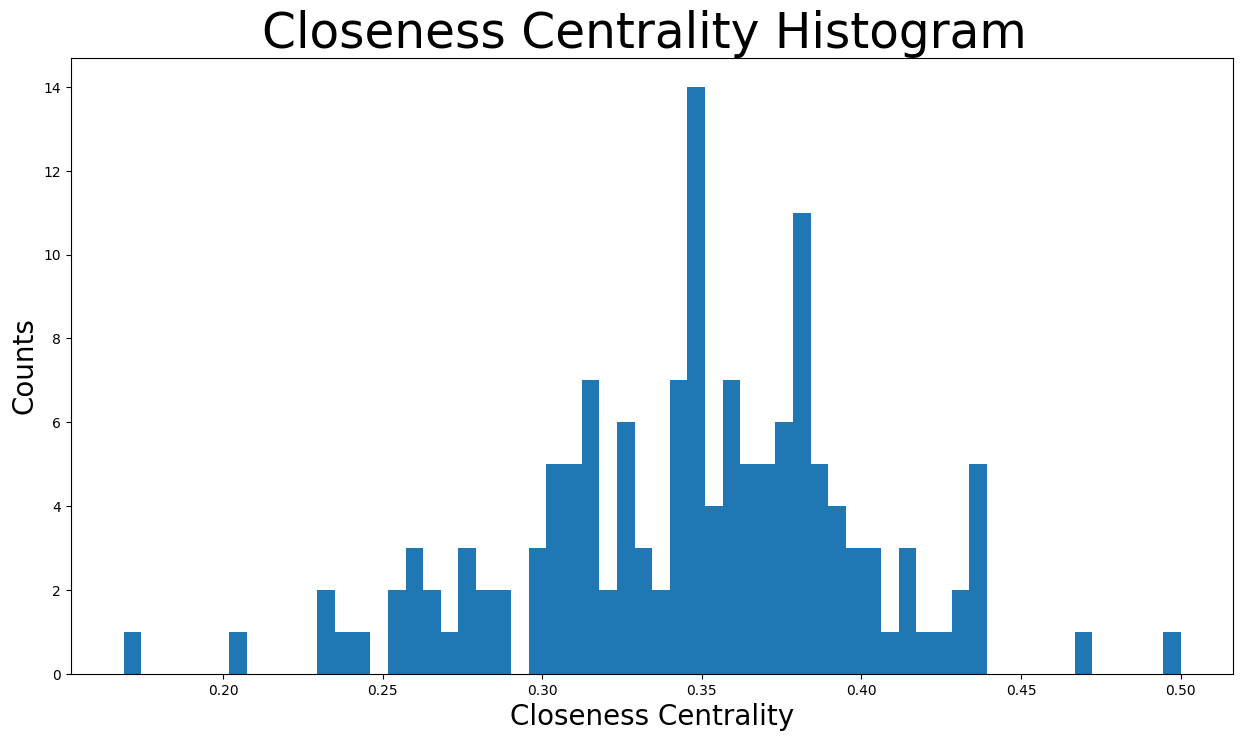

In [ ]:
plt.figure(figsize=(15, 8))
plt.hist(closeness_centrality.values(), bins=60)
plt.title("Closeness Centrality Histogram ", fontdict={"size": 35}, loc="center")
plt.xlabel("Closeness Centrality", fontdict={"size": 20})
plt.ylabel("Counts", fontdict={"size": 20})

The closeness centralities are distributed over various values from $0.17$ to $0.5$. In fact, the majority of them are found between $0.3$ and $0.45$. That means that the majority of nodes are relatively close to the center of the network and thus close to other nodes in general. However, there are some communities that are located further away, whose nodes would have the minimum closeness centralities, as seen below:

(-0.5624637394479869,
 0.8238868567221811,
 -0.5967055264924962,
 1.1517231495762101)

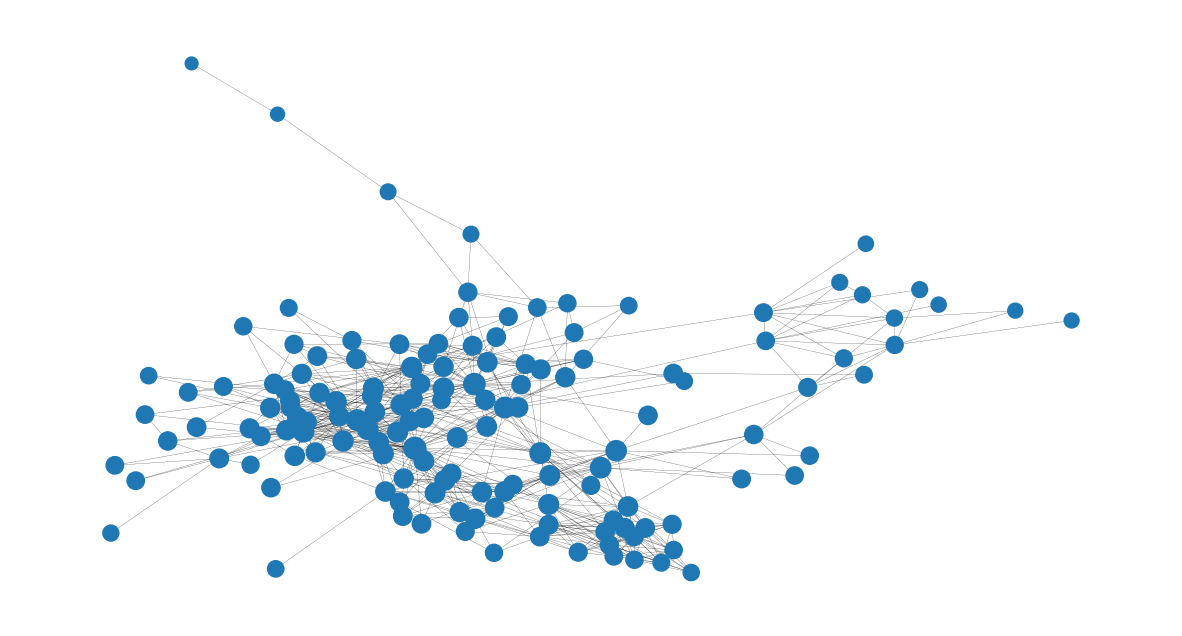

In [ ]:
# set up nodes size for a nice graph representation

node_size = [v * 500 for v in closeness_centrality.values()]
plt.figure(figsize=(15, 8))
nx.draw_networkx(G, node_size=node_size, with_labels=False, width=0.15)
plt.axis("off")

### Betweenness centrality

Betweenness centrality measures the number of times a node lies on the shortest path between other nodes, meaning it acts as a bridge. In detail, betweenness centrality of a node $v$ is the percentage of all the shortest paths of any two nodes (apart from $v$), which pass through $v$.

This measure is associated with the user's ability to influence others. A user with a high betweenness centrality acts as a bridge to many users that are not friends and thus has the ability to influence them by conveying information (e.g. by posting something or sharing a post) or even connect them via the user's circle (which would reduce the user's betweeness centrality after).

In the sketch below of a network, node $A$ lies on a bridge joining two groups of other nodes. All paths between the groups must pass
through $A$, so it has a high betweenness even though its degree is low.

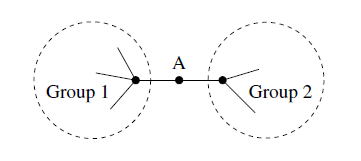

Betweenness centrality of a node $v$ is the sum of the
fraction of all-pairs shortest paths that pass through $v$

$$ c_B(v) =\sum_{s,t \in V} \frac{\sigma(s, t|v)}{\sigma(s, t)}, $$

where $V$ is the set of nodes, $\sigma(s, t)$ is the number of
shortest $(s, t)$-paths,  and $\sigma(s, t|v)$ is the number of
those paths  passing through some  node $v$ other than $s, t$.

If $s = t$, $\sigma(s, t) = 1$, and if $v \in {s, t}$, $\sigma(s, t|v) = 0$.

If True the betweenness values are normalized by 2/((n-1)(n-2)) for graphs, and 1/((n-1)(n-2)) for directed graphs where n is the number of nodes in G.

Calculate closeness centrality for nodes $A$, $G$.

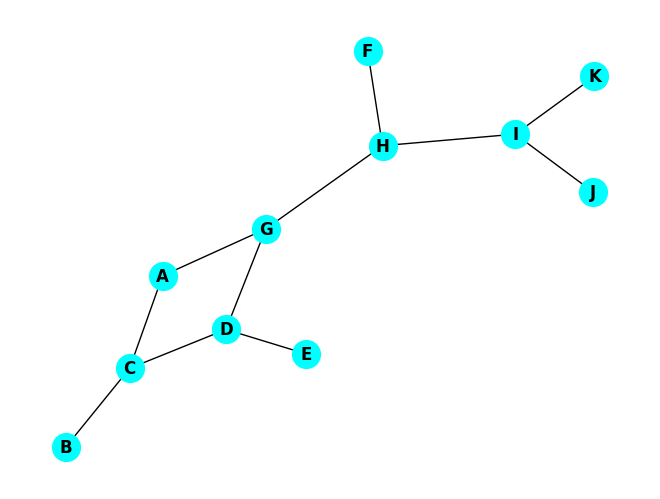

In [ ]:
nx.draw(H, node_size=400, node_color='cyan', with_labels=True, font_weight='bold')

If normalized is True the betweenness values are normalized by $2/((n-1)(n-2))$ for graphs.

In [ ]:
nx.centrality.betweenness_centrality(H, normalized=False)

{'A': 6.0,
 'B': 0.0,
 'C': 10.0,
 'D': 15.0,
 'E': 0.0,
 'F': 0.0,
 'G': 26.0,
 'H': 27.0,
 'I': 17.0,
 'J': 0.0,
 'K': 0.0}

In [ ]:
6*2/(10*9)

0.13333333333333333

In [ ]:
nx.centrality.betweenness_centrality(H, normalized=True)

{'A': 0.13333333333333333,
 'B': 0.0,
 'C': 0.22222222222222224,
 'D': 0.33333333333333337,
 'E': 0.0,
 'F': 0.0,
 'G': 0.5777777777777778,
 'H': 0.6,
 'I': 0.37777777777777777,
 'J': 0.0,
 'K': 0.0}

The nodes of $G$ with the $10$ highest betweenness centralities :

In [ ]:
 # save results in a variable to use again
betweenness_centrality = nx.centrality.betweenness_centrality(G)
(sorted(betweenness_centrality.items(), key=lambda item: item[1], reverse=True))[:10]

[(105, 0.19400604344556296),
 (17, 0.11088210445609471),
 (48, 0.09673142009207425),
 (91, 0.09118959870866389),
 (32, 0.08554735598477585),
 (95, 0.07579595400584722),
 (141, 0.06345441275176905),
 (22, 0.05846852533268458),
 (72, 0.05833907970763193),
 (51, 0.05199434696409222)]

Looking at the results, the node $105$ has a betweenness centrality of $0.19$, meaning it lies on almost $20\%$ of the total shortest paths between other nodes.

Nodes $105, 17$ have both the highest degree and betweenness centralities and are *spotlight nodes*. That indicates that those nodes are both the most popular ones in this network and can also influence and spread information in the network.

The distribution of betweenness centralities will be plotted:

Text(0, 0.5, 'Counts')

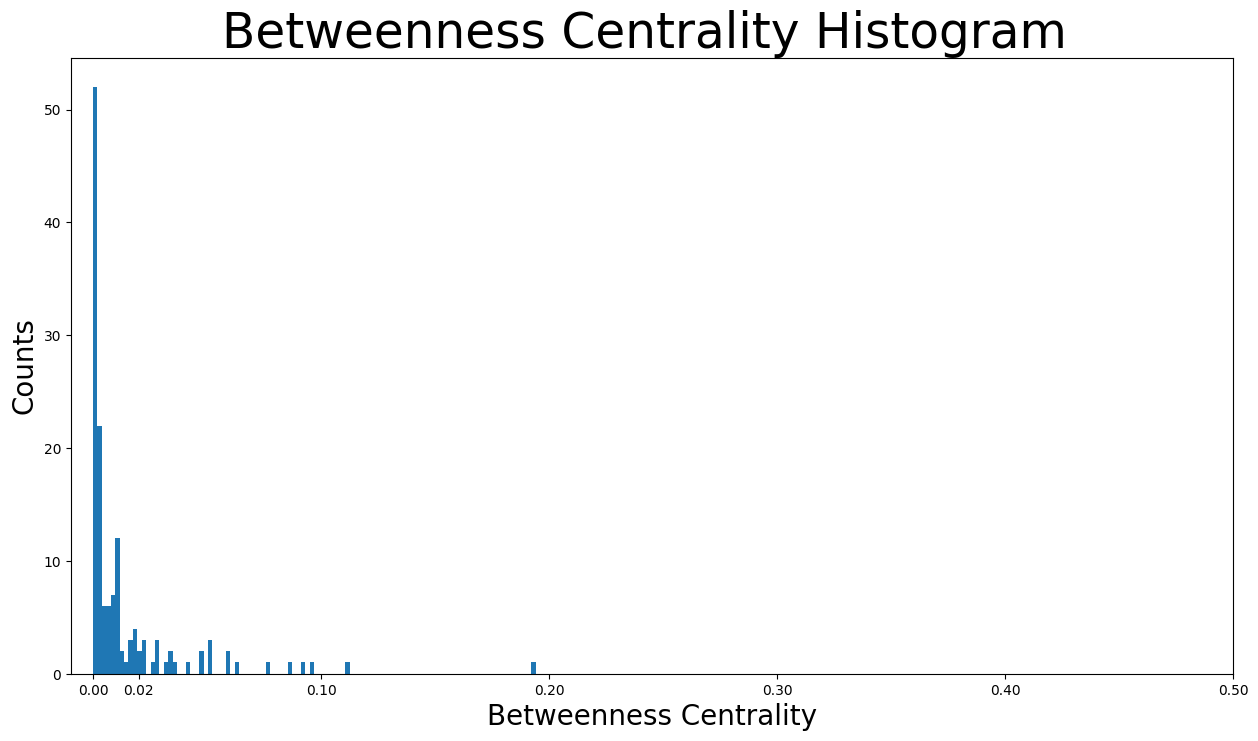

In [ ]:
plt.figure(figsize=(15, 8))
plt.hist(betweenness_centrality.values(), bins=100)
plt.xticks(ticks=[0, 0.02, 0.1, 0.2, 0.3, 0.4, 0.5])  # set the x axis ticks
plt.title("Betweenness Centrality Histogram ", fontdict={"size": 35}, loc="center")
plt.xlabel("Betweenness Centrality", fontdict={"size": 20})
plt.ylabel("Counts", fontdict={"size": 20})

(-0.7435563134648651,
 1.1656772967545799,
 -1.1498963461298244,
 1.1010726679753517)

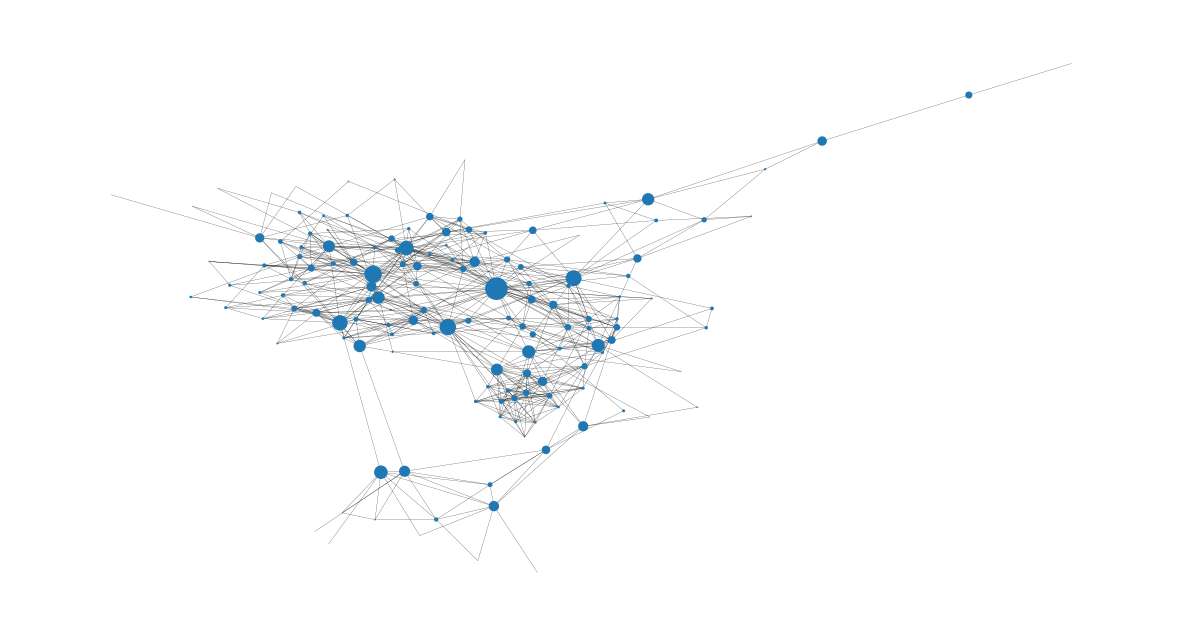

In [ ]:
node_size = [
    v * 1200 for v in betweenness_centrality.values()
]  # set up nodes size for a nice graph representation
plt.figure(figsize=(15, 8))
nx.draw_networkx(G, node_size=node_size, with_labels=False, width=0.15)
plt.axis("off")

### Eigenvector Centrality
Eigenvector centrality is the metric to show how connected a node is to other important nodes in the network. It measures a node's influence based on how well it is connected inside the network and how many links its connections have and so on. This measure can identify the nodes with the most influence over the whole network. A high eigenvector centrality means that the node is connected to other nodes who themselves have high eigenvector centralities.

Eigenvector centrality computes the centrality for a node by adding
the centrality of its predecessors. In the case of undirected graphs, the centrality for node $i$ is the
$i$-th element of a right eigenvector associated with the eigenvalue $\lambda$
of maximum modulus that is positive. Such an eigenvector $x$ is
defined up to a multiplicative constant by the equation
$$Ax = \lambda x, $$

where $A$ is the adjacency matrix of the graph $G$.

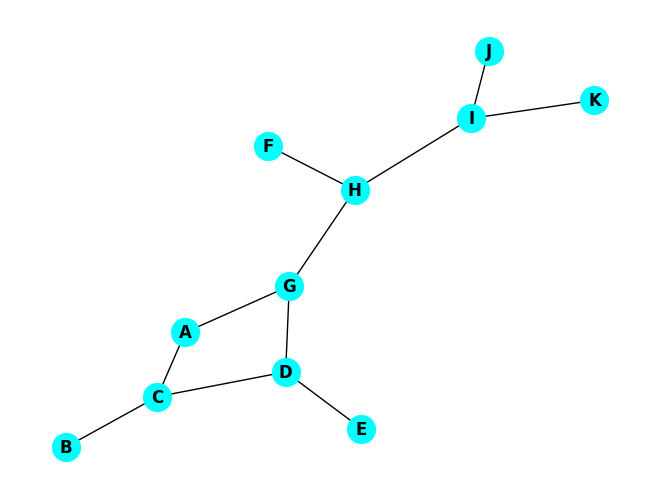

In [ ]:
nx.draw(H, node_size=400, node_color='cyan', with_labels=True, font_weight='bold')

In [ ]:
A = nx.adjacency_matrix(H).todense()

In [ ]:
print(A)

[[0 0 1 0 0 0 1 0 0 0 0]
 [0 0 1 0 0 0 0 0 0 0 0]
 [1 1 0 1 0 0 0 0 0 0 0]
 [0 0 1 0 1 0 1 0 0 0 0]
 [0 0 0 1 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 1 0 0 0]
 [1 0 0 1 0 0 0 1 0 0 0]
 [0 0 0 0 0 1 1 0 1 0 0]
 [0 0 0 0 0 0 0 1 0 1 1]
 [0 0 0 0 0 0 0 0 1 0 0]
 [0 0 0 0 0 0 0 0 1 0 0]]


In [ ]:
from numpy import linalg as LA

In [ ]:
eigenvalues, eigenvectors = LA.eig(A)

In [ ]:
eigenvalues

array([ 2.41421356,  1.84775907, -2.41421356, -1.84775907,  0.76536686,
        0.41421356, -0.41421356, -0.76536686,  1.        , -1.        ,
        0.        ])

In [ ]:
x = eigenvectors[:,0]
l = eigenvalues[0]

print(x)

[0.36725478 0.16787465 0.40528526 0.44331573 0.18362739 0.14559691
 0.48134621 0.35150204 0.22165787 0.09181369 0.09181369]


In [ ]:
np.dot(A, x)

array([0.88663147, 0.40528526, 0.97844516, 1.07025885, 0.44331573,
       0.35150204, 1.16207255, 0.84860099, 0.53512943, 0.22165787,
       0.22165787])

In [ ]:
l*x

array([0.88663147, 0.40528526, 0.97844516, 1.07025885, 0.44331573,
       0.35150204, 1.16207255, 0.84860099, 0.53512943, 0.22165787,
       0.22165787])

In [ ]:
nx.centrality.eigenvector_centrality(H)

{'A': 0.36725170035175286,
 'B': 0.16787157202707984,
 'C': 0.40527956903406565,
 'D': 0.443311380582172,
 'E': 0.1836250335816161,
 'F': 0.14560093195145987,
 'G': 0.48134620986917237,
 'H': 0.35150946712917597,
 'I': 0.22166757278673263,
 'J': 0.09181894755113106,
 'K': 0.09181894755113106}

The nodes from $G$ with the highest eigenvector centralities :

In [ ]:
# save results in a variable to use again
eigenvector_centrality = nx.centrality.eigenvector_centrality(G)
(sorted(eigenvector_centrality.items(), key=lambda item: item[1], reverse=True))[:10]

[(105, 0.2513631026471415),
 (31, 0.21410710260355367),
 (136, 0.21070164213770012),
 (132, 0.2105711443392644),
 (20, 0.2031133349707531),
 (19, 0.1986534849023115),
 (69, 0.1942352880323705),
 (67, 0.19385055532336717),
 (48, 0.18439388569559872),
 (2, 0.1748292030440573)]

Checking the results:
* Node $105$ has the highest eigenvector centrality with $0.251$. This node is  a *spotlight node* and can surely be considered the most important node in this network in terms of overall influence to the whole network. In fact, this node also has some of the highest degree centralities and  betweenness centralities, making the user very popular and influencious to other nodes.
* Nodes $31, 136, 20$ even though they are not spotlight nodes, have some of the highest eigenvector centralities with around $0.2 - 0.21$. Very interesting is the fact that all those nodes are identified for the first time, meaning they have neither the heighest degree, betweenness or closeness centralities in this graph.

In [ ]:
[n for n in G.neighbors(31)]

[2, 3, 4, 18, 19, 20, 22, 27, 28, 48, 50, 65, 67, 69, 72, 132, 134, 136]

In [ ]:
[n for n in G.neighbors(136)]

[2, 3, 4, 19, 20, 27, 28, 29, 31, 48, 54, 65, 67, 69, 71, 72, 132]

In [ ]:
[n for n in G.neighbors(20)]

[2, 3, 4, 18, 19, 27, 28, 29, 31, 54, 65, 67, 69, 71, 107, 132, 136]

Text(0, 0.5, 'Counts')

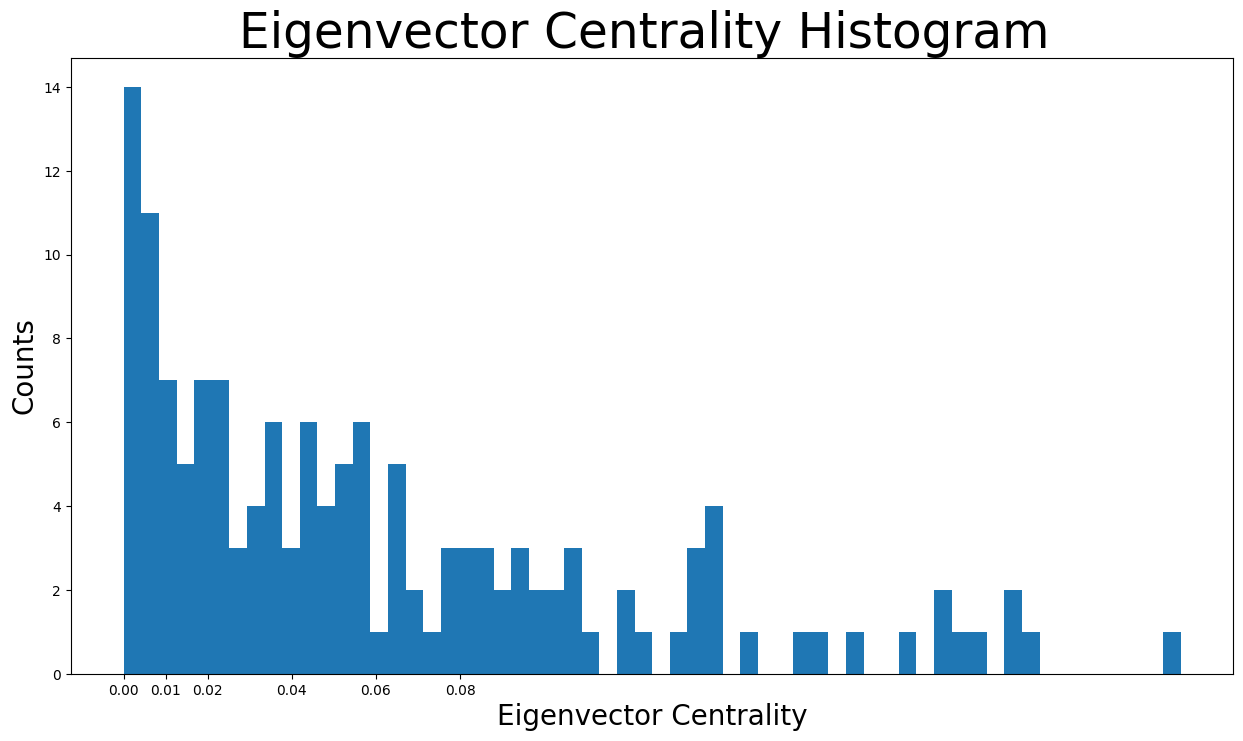

In [ ]:
plt.figure(figsize=(15, 8))
plt.hist(eigenvector_centrality.values(), bins=60)
plt.xticks(ticks=[0, 0.01, 0.02, 0.04, 0.06, 0.08])  # set the x axis ticks
plt.title("Eigenvector Centrality Histogram ", fontdict={"size": 35}, loc="center")
plt.xlabel("Eigenvector Centrality", fontdict={"size": 20})
plt.ylabel("Counts", fontdict={"size": 20})

## Clustering Effects
The clustering coefficient of a node $v$ is defined as the probability that two randomly selected friends of $v$ are friends with each other. As a result, the average clustering coefficient is the average of clustering coefficients of all the nodes. The closer the average clustering coefficient is to $1$, the more complete the graph will be because there's just one giant component. Lastly, it is a sign of triadic closure because the more complete the graph is, the more triangles will usually arise.

For unweighted graphs, the clustering of a node $u$ is the fraction of possible triangles through that node that exist,

$$ c_u = \frac{2 T(u)}{\deg(u)(\deg(u)-1)},$$

where $T(u)$ is the number of triangles through node $u$ and
$\deg(u)$ is the degree of $u$.


The clustering coefficient for the graph is the average,
$$ C = \frac{1}{n}\sum_{u \in G} c_г,$$

 where $n$ is the number of nodes in $G$.

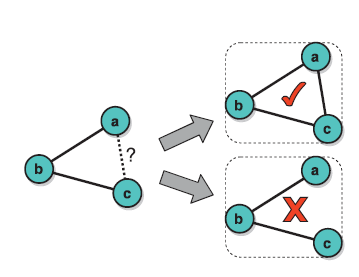

In [ ]:
H.add_edges_from([("C", "G"), ("K", "J")])

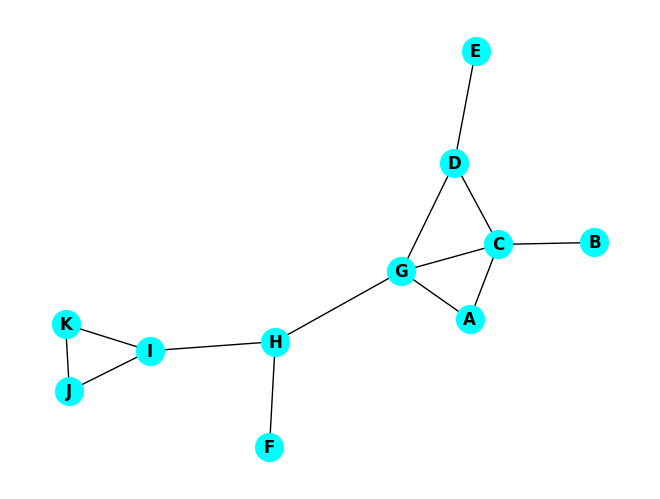

In [ ]:
nx.draw(H, node_size=400, node_color='cyan', with_labels=True, font_weight='bold')

In [ ]:
print(nx.clustering(H))

{'A': 1.0, 'B': 0, 'C': 0.3333333333333333, 'D': 0.3333333333333333, 'E': 0, 'F': 0, 'G': 0.3333333333333333, 'H': 0, 'I': 0.3333333333333333, 'J': 1.0, 'K': 1.0}


In [ ]:
sum(nx.clustering(H).values())/11

0.3939393939393939

In [ ]:
nx.average_clustering(H)

0.3939393939393939

In [ ]:
nx.average_clustering(G)

0.43390702914792223

Now the clustering coefficient distribution will be displayed:

Text(0, 0.5, 'Counts')

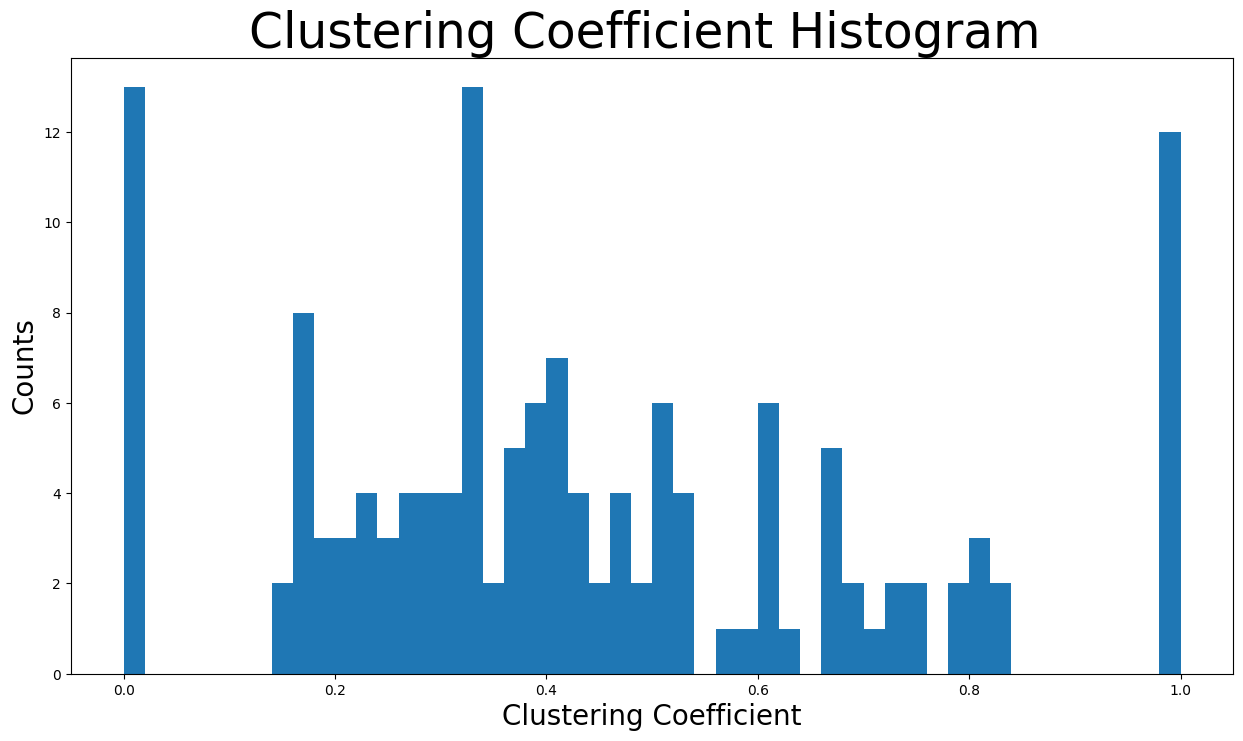

In [ ]:
plt.figure(figsize=(15, 8))
plt.hist(nx.clustering(G).values(), bins=50)
plt.title("Clustering Coefficient Histogram ", fontdict={"size": 35}, loc="center")
plt.xlabel("Clustering Coefficient", fontdict={"size": 20})
plt.ylabel("Counts", fontdict={"size": 20})

In [ ]:
triangles_per_node = list(nx.triangles(G).values())
sum(triangles_per_node) / 3  # divide by 3 because each triangle is counted once for each node

889.0

 Now the average number of triangles that a node is a part of:

In [ ]:
np.mean(triangles_per_node)

18.65034965034965

Due to having some nodes that belong to a great many triangles, the metric of median will give us a better understanding:

In [ ]:
np.median(triangles_per_node)

11.0

In conclusion, the high average clustering coefficient together with the huge number of triangles are signs of the triadic closure. In detail, the triadic closure means that as time goes on, new edges tend to form between two users that have one or more mutual friends. That can be explained by the fact that Facebook usually suggests new friends to a user when there are many mutual friends between the user and the new friend to be added. Also, there is a source of latent stress. For example, if node $A$ is friends with
node $B$ and $C$,  some tension builds up if $B$ and $C$ are not friends with each other.

# Exercises

1. Consider the networks in figures below. For nodes $g, f$ (fig. 1) and node $3$ (figs. 2a and 2b) calculate the values of degree, closeness and betweeness centralities.

2. Create graphs and calculate the values of degree, closeness and betweeness centralities for the same nodes. Compare your results.

3. Calculate the eigenvector centralities for the same nodes.

Fig. 1

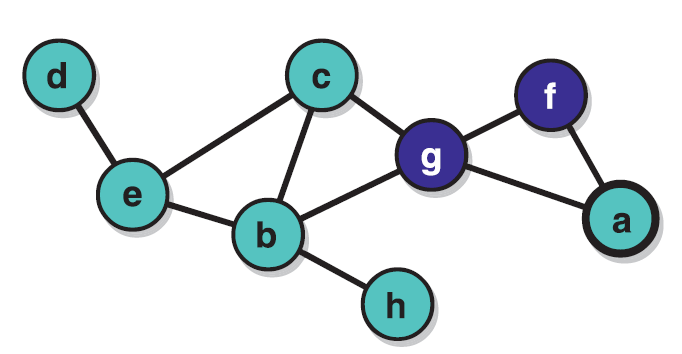

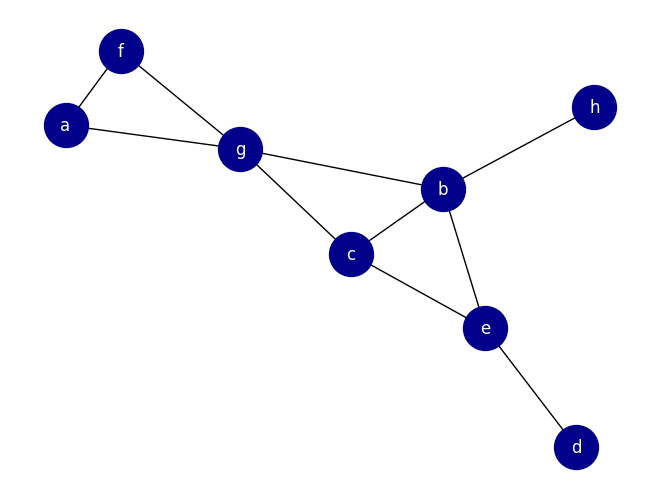

In [6]:
import networkx as nx
import matplotlib.pyplot as plt

# 直接使用字母作为节点
G = nx.Graph([('d', 'e'), ('e', 'c'), ('c', 'g'), ('g', 'f'), ('f', 'a'), ('e', 'b'), ('b', 'c'), ('b', 'g'), ('b', 'h'), ('g', 'a')])

nx.draw(
    G, with_labels=True, node_size=1000, font_color="White", node_color="darkblue"
)
plt.show()

In [7]:
print(G.degree('g'))
print(G.degree('f'))

4
2


In [24]:
shortest_path_lengths_G = dict(nx.all_pairs_shortest_path_length(G))
shortest_path_lengths_G['g']
print(f'Closeness centrality for node g: {7/sum(list(shortest_path_lengths_G['g'].values())):5.4f}')
shortest_path_lengths_G['f']
print(f'Closeness centrality for node f: {7/sum(list(shortest_path_lengths_G['f'].values())):5.4f}')

Closeness centrality for node g: 0.6364
Closeness centrality for node f: 0.4375


In [29]:
print(nx.centrality.betweenness_centrality(G, normalized=False)['f'])
print(nx.centrality.betweenness_centrality(G, normalized=False)['g'])

0.0
10.0


In [30]:
print(nx.centrality.betweenness_centrality(G, normalized=True)['f'])
print(nx.centrality.betweenness_centrality(G, normalized=True)['g'])

0.0
0.47619047619047616


In [15]:
A = nx.adjacency_matrix(G).todense()
print(A)

[[0 1 0 0 0 0 0 0]
 [1 0 1 0 0 0 1 0]
 [0 1 0 1 0 0 1 0]
 [0 0 1 0 1 1 1 0]
 [0 0 0 1 0 1 0 0]
 [0 0 0 1 1 0 0 0]
 [0 1 1 1 0 0 0 1]
 [0 0 0 0 0 0 1 0]]


In [17]:
from numpy import linalg as LA
eigenvalues, eigenvectors = LA.eig(A)
eigenvalues

array([ 2.96470719,  1.67135384,  0.64044563,  0.11448281, -2.04507012,
       -1.        , -1.34591935, -1.        ])

In [18]:
x = eigenvectors[:,0]
l = eigenvalues[0]

print(x)

[-0.12274265 -0.36389601 -0.45681243 -0.49112906 -0.2499757  -0.2499757
 -0.49929003 -0.16841125]


In [19]:
nx.centrality.eigenvector_centrality(G)

{'d': 0.12274158721769104,
 'e': 0.36389423601139337,
 'c': 0.4568116006080182,
 'g': 0.4911305155607484,
 'f': 0.249977866767046,
 'a': 0.249977866767046,
 'b': 0.49928896072778123,
 'h': 0.16841060521388343}

Fig. 2

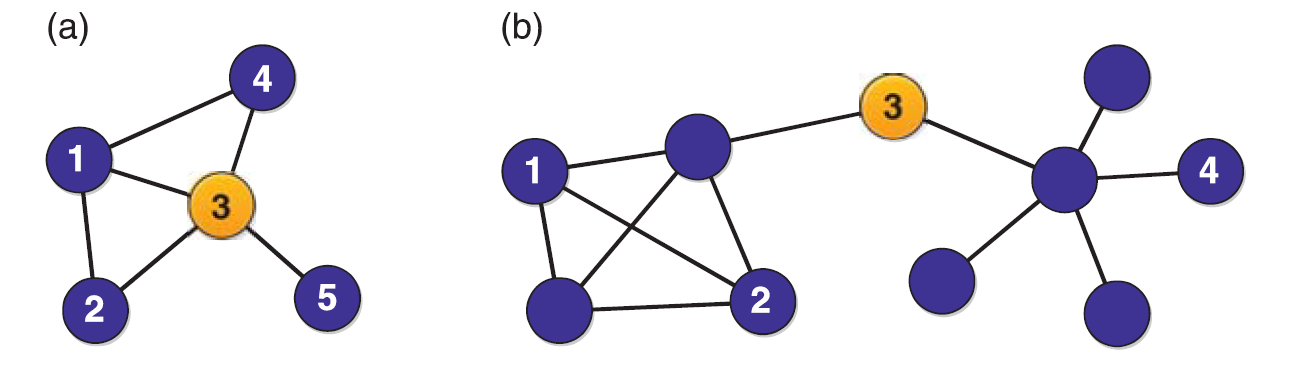

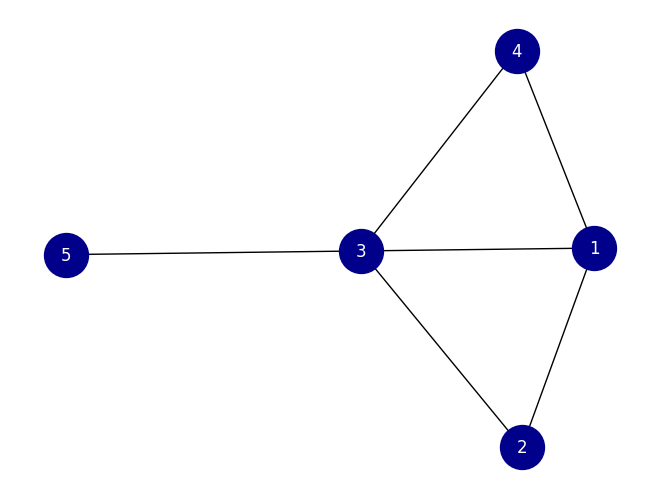

In [22]:
import networkx as nx
import matplotlib.pyplot as plt

# 直接使用字母作为节点
G1 = nx.Graph([(1, 2), (2, 3), (1, 3), (1, 4), (3, 4), (3, 5)])

nx.draw(
    G1, with_labels=True, node_size=1000, font_color="White", node_color="darkblue"
)
plt.show()

In [23]:
print(G1.degree(3))

4


In [35]:
shortest_path_lengths_G1 = dict(nx.all_pairs_shortest_path_length(G1))
shortest_path_lengths_G1[3]
print(f'Closeness centrality for node 3: {4/sum(list(shortest_path_lengths_G1[3].values())):5.4f}')

Closeness centrality for node 3: 1.0000


In [26]:
nx.centrality.betweenness_centrality(G1, normalized=False)

{1: 0.5, 2: 0.0, 3: 3.5, 4: 0.0, 5: 0.0}

In [27]:
nx.centrality.betweenness_centrality(G1, normalized=True)

{1: 0.08333333333333333, 2: 0.0, 3: 0.5833333333333333, 4: 0.0, 5: 0.0}

In [28]:
A1 = nx.adjacency_matrix(G1).todense()
print(A1)

[[0 1 1 1 0]
 [1 0 1 0 0]
 [1 1 0 1 1]
 [1 0 1 0 0]
 [0 0 1 0 0]]


In [31]:
eigenvalues, eigenvectors = LA.eig(A1)
eigenvalues

array([ 2.68554393e+00, -1.74911755e+00, -1.27133037e+00,  3.34903985e-01,
       -2.73515888e-17])

In [32]:
nx.centrality.eigenvector_centrality(G1)

{1: 0.5236826290621273,
 2: 0.41191709737006765,
 3: 0.5825392535755104,
 4: 0.41191709737006765,
 5: 0.21691733875073665}

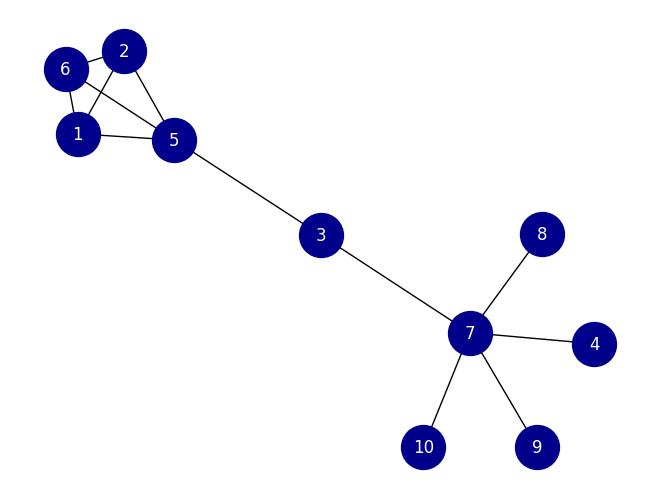

In [33]:
import networkx as nx
import matplotlib.pyplot as plt

# 直接使用字母作为节点
G2 = nx.Graph([(1, 2), (1, 5), (1, 6), (5, 6), (2, 5), (2, 6), (5, 3), (3, 7), (7, 8), (7, 4), (7, 9), (7, 10)])

nx.draw(
    G2, with_labels=True, node_size=1000, font_color="White", node_color="darkblue"
)
plt.show()

In [34]:
print(G2.degree(3))

2


In [36]:
shortest_path_lengths_G2 = dict(nx.all_pairs_shortest_path_length(G2))
shortest_path_lengths_G2[3]
print(f'Closeness centrality for node 3: {9/sum(list(shortest_path_lengths_G2[3].values())):5.4f}')

Closeness centrality for node 3: 0.5625


In [37]:
nx.centrality.betweenness_centrality(G2, normalized=False)

{1: 0.0,
 2: 0.0,
 5: 18.0,
 6: 0.0,
 3: 20.0,
 7: 26.0,
 8: 0.0,
 4: 0.0,
 9: 0.0,
 10: 0.0}

In [38]:
nx.centrality.betweenness_centrality(G2, normalized=True)

{1: 0.0,
 2: 0.0,
 5: 0.5,
 6: 0.0,
 3: 0.5555555555555556,
 7: 0.7222222222222222,
 8: 0.0,
 4: 0.0,
 9: 0.0,
 10: 0.0}

In [39]:
A2 = nx.adjacency_matrix(G2).todense()
print(A2)

[[0 1 1 1 0 0 0 0 0 0]
 [1 0 1 1 0 0 0 0 0 0]
 [1 1 0 1 1 0 0 0 0 0]
 [1 1 1 0 0 0 0 0 0 0]
 [0 0 1 0 0 1 0 0 0 0]
 [0 0 0 0 1 0 1 1 1 1]
 [0 0 0 0 0 1 0 0 0 0]
 [0 0 0 0 0 1 0 0 0 0]
 [0 0 0 0 0 1 0 0 0 0]
 [0 0 0 0 0 1 0 0 0 0]]


In [40]:
eigenvalues, eigenvectors = LA.eig(A2)
eigenvalues

array([ 3.10537762,  2.22726128,  0.36219039, -2.31585539, -1.        ,
       -1.3789739 , -1.        ,  0.        ,  0.        ,  0.        ])

In [41]:
nx.centrality.eigenvector_centrality(G2)

{1: 0.4719702140128343,
 2: 0.4719702140128343,
 5: 0.5217065722550938,
 6: 0.4719702140128343,
 3: 0.20418555643941447,
 7: 0.11236353638623062,
 8: 0.03618458909600195,
 4: 0.03618458909600195,
 9: 0.03618458909600195,
 10: 0.03618458909600195}